# Student Dataset

In [5]:
# Libraries
import hashlib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
# Dataset Class
class StudentDataset:
    """
        A class that generates and visualizes a student demographic.
        Parameters:
            num_students (int): The number of students to generate.
            seed (int): The random seed for reproducibility.
    """

    def __init__(self, num_students: int, seed: int, username: str):
        """
            Sets up the initial variables like num_students, seed and calls the data generation methods.
        """
        self.num_students = num_students
        self.seed = seed
        self.username = username
        np.random.seed(seed) # Set the deterministic seed generated based on username in the previous cell
        self.data = self.assemble_dataframe()

    def assemble_dataframe(self):
        """
            Assembles the full dataset from gender, major, program, and GPA.
            Returns:
                pd.DataFrame: A DataFrame containing the student demographic data.
        """
        
        gender = self.generate_gender()
        major = self.generate_major()
        program = self.generate_program(major)
        gpa = self.generate_gpa(major)

        data = {
            'Gender': gender,
            'Major': major,
            'Program': program,
            'GPA': gpa
        }

        return pd.DataFrame(data)

    def generate_gender(self) -> list[str]:
        """
            Generates a list of genders among {Male, Female, Other} with probabilities {0.65, 0.33, 0.02} respectively
            Returns:
                list[str]: A list of genders for the students.
        """

        genders = ["Male", "Female", "Other"]
        probs = [0.65, 0.33, 0.02]
        return np.random.choice(genders, size=self.num_students, p=probs).tolist()

    def generate_major(self) -> list[str]:
        """
            Generates a list of majors among {B.Tech, MS, PhD} with probabilities {0.7, 0.2, 0.1} respectively
            Returns:
                list[str]: A list of majors for the students.
        """

        majors = ["B.Tech", "MS", "PhD"]
        probs = [0.7, 0.2, 0.1]
        return np.random.choice(majors, size=self.num_students, p=probs).tolist()

    def generate_program(self, majors: list[str]) -> list[str]:
        """
            Generates a list of programs among {CSE, ECE, CHD, CND} conditioned on the major.
            Parameters:
                majors (list[str]): A list of majors for the students.
            Returns:
                list[str]: A list of programs for the students.
        """

        programs = []
        for major in majors:
            if major == "B.Tech":
                programs.append(np.random.choice(["CSE", "ECE", "CHD", "CND"], p=[0.4, 0.4, 0.1, 0.1]))
            elif major == "MS":
                programs.append(np.random.choice(["CSE", "ECE", "CHD", "CND"], p=[0.3, 0.3, 0.2, 0.2]))
            else:
                programs.append(np.random.choice(["CSE", "ECE", "CHD", "CND"], p=[0.25, 0.25, 0.25, 0.25]))

        return programs

    def generate_gpa(self, majors: list[str]) -> list[float]:
        """
            Generates a list of GPAs conditioned on the major. Values are clipped to [4.0, 10.0]
            Parameters:
                majors (list[str]): A list of majors for the students.
            Returns:
                list[float]: A list of GPAs for the students.
        """

        gpa = []
        for major in majors:
            if major == "B.Tech":
                gpa.append(np.clip(np.random.normal(7.0, 1.0), 4.0, 10.0))
            elif major == "MS":
                gpa.append(np.clip(np.random.normal(8.0, 0.49), 4.0, 10.0))
            else:
                gpa.append(np.clip(np.random.normal(8.3, 0.25), 4.0, 10.0))

        return gpa
        
    def get_full_dataframe(self) -> pd.DataFrame:
        """
            Returns the full DataFrame containing the student demographic data.
            Returns:
                pd.DataFrame: The DataFrame with student demographics.
        """
        return self.data

    #----------------- VISUALIZATION -----------------

    def _add_username(self) -> None:
        plt.text(0.95, 0.95, self.username, ha="right", va="top", transform=plt.gca().transAxes, fontsize=10, color="gray", alpha=0.7)

    def plot_gender_distribution(self)-> None:
        """
            Plots the gender distribution of the students. 
            Prints the stats as well.
            Histogram and Piechart are plotted beside each other.
        """
        
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        sns.histplot(data=self.data, x="Gender", discrete=True, stat="count", kde=False)
        plt.title("Gender Distribution (Histogram)")
        plt.grid(True, alpha=0.25)
        self._add_username()

        plt.subplot(1, 2, 2)
        plt.pie(self.data["Gender"].value_counts(), labels=self.data["Gender"].value_counts().index, autopct="%1.1f%%")
        plt.title("Gender Distribution (Pie Chart)")
        self._add_username()
        plt.show()

        print(self.data["Gender"].value_counts())

    def plot_major_distribution(self)-> None:
        """
            Plots the major distribution of the students.
            Prints the stats as well.
            Histogram and Piechart are plotted beside each other.
        """
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        sns.histplot(data=self.data, x="Major", discrete=True, stat="count", kde=False)
        plt.title("Major Distribution (Histogram)")
        plt.grid(True, alpha=0.25)
        self._add_username()

        plt.subplot(1, 2, 2)
        plt.pie(self.data["Major"].value_counts(), labels=self.data["Major"].value_counts().index, autopct="%1.1f%%")
        plt.title("Major Distribution (Pie Chart)")
        self._add_username()
        plt.show()

        print(self.data["Major"].value_counts())

    def plot_program_distribution(self)-> None:
        """
            Plots the program distribution of ALL students. 
            Prints the stats as well.
            Histogram and Piechart are plotted beside each other.
        """
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        sns.histplot(data=self.data, x="Program", discrete=True, stat="count", kde=False)
        plt.title("Program Distribution (Histogram)")
        self._add_username()
        plt.grid(True, alpha=0.25)

        plt.subplot(1, 2, 2)
        plt.pie(self.data["Program"].value_counts(), labels=self.data["Program"].value_counts().index, autopct="%1.1f%%")
        plt.title("Program Distribution")
        self._add_username()
        plt.show()

        print(self.data["Program"].value_counts())

    def plot_gpa_distribution(self, bins: int = 20)-> None:
        """
            Plots the GPA distribution of the students.
            Prints the stats as well.
        """
        plt.figure(figsize=(6, 5))
        sns.histplot(self.data["GPA"], bins=bins)
        plt.title("GPA Distribution")
        plt.xlabel("GPA")
        plt.ylabel("Frequency")
        self._add_username()
        plt.grid(True, alpha=0.5)
        plt.show()

        print(self.data["GPA"].describe())

    def plot_program_by_major(self)-> None:
        """
            Plots a bar chart of the number of students in each program, grouped by major. X axis has majors and group of bars are programs
            Prints the stats as well.
        """
        plt.figure(figsize=(12, 6))
        sns.countplot(data=self.data, x="Major", hue="Program", dodge=True, order=self.data["Major"].value_counts().index)
        plt.title("Program Distribution by Major")
        plt.xlabel("Major")
        plt.ylabel("Count")
        self._add_username()
        plt.legend(title="Program", loc='center right')
        plt.grid(True, alpha=0.5)
        plt.show()

        print(self.data.groupby("Major")["Program"].value_counts())

    def plot_gpa_by_major(self)-> None:
        """
            Plots a violin plot of GPA on Y-axis and different Majors on the X-axis.
            Prints the stats as well.
        """
        plt.figure(figsize=(12,6))
        ax = sns.violinplot(data=self.data, x="Major", y="GPA", inner=None, palette="Set2", hue="Major")
        for i, m in enumerate(self.data["Major"].value_counts().index):
            g = self.data.loc[self.data["Major"]==m, "GPA"]
            q1,q2,q3 = np.percentile(g,[25,50,75])
            plt.vlines(i, g.min(), g.max(), color="k", lw=1.5)
            plt.vlines(i, q1, q3, color="k", lw=5)
            plt.scatter(i, q2, color="w", edgecolor="k", zorder=3)
        plt.title("GPA Distribution by Major"); plt.xlabel("Major"); plt.ylabel("GPA")
        self._add_username()
        plt.grid(True)
        plt.show()

        print(self.data.groupby("Major")["GPA"].describe())

    def plot_gpa_by_program(self)-> None:
        """
            Plots the GPA distribution of students in each program.
            Prints the stats as well.
        """
        plt.figure(figsize=(12, 6))
        sns.boxplot(data=self.data, x="Program", y="GPA", palette='Set2', hue="Program")
        plt.title("GPA Distribution by Program")
        plt.xlabel("Program")
        plt.ylabel("GPA")
        self._add_username()
        plt.grid(True, alpha=0.25)
        plt.show()

        print(self.data.groupby("Program")["GPA"].describe())

    def plot_gpa_by_program_and_major(self)-> None:
        """
            Plots the GPA distribution of students in each program and major.
            Prints the stats as well.
        """
        plt.figure(figsize=(12, 6))
        sns.boxplot(data=self.data, x="Program", y="GPA", hue="Major", palette='Set2')
        plt.title("GPA Distribution by Program and Major")
        plt.xlabel("Program")
        plt.ylabel("GPA")
        self._add_username()
        plt.grid(True, alpha=0.25)
        plt.show()

        print(self.data.groupby(["Program", "Major"])["GPA"].describe())

    def plot_sampled_dataset(self)-> None:
        """
            Samples 100 random students and plots gender, major, program, GPA in different suitable plots. 
            Prints the stats as well.
        """
        sampled_data = self.data.sample(n=100, random_state=self.seed)
        # Plotting Gender Distribution
        plt.figure(figsize=(6, 5))
        sns.countplot(data=sampled_data, x="Gender", palette="Set2", hue="Gender")
        plt.title("Gender Distribution (Sampled)")
        plt.xlabel("Gender")
        plt.ylabel("Count")
        self._add_username()
        plt.grid(True, alpha=0.5)
        plt.show()

        print(sampled_data["Gender"].value_counts())

        # Plotting Major Distribution
        plt.figure(figsize=(12, 6))
        sns.countplot(data=sampled_data, x="Major", palette="Set2", hue="Major")
        plt.title("Major Distribution (Sampled)")
        plt.xlabel("Major")
        plt.ylabel("Count")
        self._add_username()
        plt.grid(True, alpha=0.5)
        plt.show()

        print(sampled_data["Major"].value_counts())

        # Plotting Program Distribution
        plt.figure(figsize=(12, 6))
        sns.countplot(data=sampled_data, x="Program", palette="Set2", hue="Program")
        plt.title("Program Distribution (Sampled)")
        plt.xlabel("Program")
        plt.ylabel("Count")
        self._add_username()
        plt.grid(True, alpha=0.5)
        plt.show()

        print(sampled_data["Program"].value_counts())

        # Plotting GPA Distribution
        plt.figure(figsize=(6, 5))
        sns.histplot(sampled_data["GPA"], bins=20)
        plt.title("GPA Distribution (Sampled)")
        plt.xlabel("GPA")
        plt.ylabel("Frequency")
        self._add_username()
        plt.grid(True, alpha=0.5)
        plt.show()

        print(sampled_data["GPA"].describe())

    def plot_entire_dataset_summary(self) -> None: #TODO Finalize the plot setup
        """
            Plots summary visualizations for the entire dataset.
        """
        df = self.data

        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        sns.boxplot(x="Major", y="GPA", hue="Gender", data=df, ax=axes[0])
        axes[0].set_title("GPA Distribution by Major and Gender")
        self._add_username()

        sns.boxplot(x="Program", y="GPA", hue="Gender", data=df, ax=axes[1])
        axes[1].set_title("GPA Distribution by Program and Gender")
        self._add_username()

        sns.boxplot(x="Major", y="GPA", hue="Program", data=df, ax=axes[2])
        axes[2].set_title("GPA Distribution by Major and Program")
        self._add_username()

        plt.tight_layout()
        plt.show()

        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        sns.heatmap(data=df.pivot_table(index="Gender", columns="Major", values="GPA", aggfunc="count"), annot=True, fmt="d", cmap="coolwarm", ax=axes[0])
        axes[0].set_title("Student Count Heatmap by Major and Gender")
        self._add_username()

        sns.heatmap(data=df.pivot_table(index="Gender", columns="Program", values="GPA", aggfunc="count"), annot=True, fmt="d", cmap="coolwarm", ax=axes[1])
        axes[1].set_title("Student Count Heatmap by Program and Gender")
        self._add_username()

        sns.heatmap(data=df.pivot_table(index="Program", columns="Major", values="GPA",  aggfunc="count"), annot=True, fmt="d", cmap="coolwarm", ax=axes[2])
        axes[2].set_title("Student Count Heatmap by Major and Program")
        self._add_username()

        plt.tight_layout()
        plt.show()

    #----------------- STATISTICS -----------------
    
    def gpa_mean_std(self)-> tuple[float, float]:
        """
            Returns the mean and standard deviation of GPA.
            Returns:
                tuple: (mean, std)
        """
        return self.data["GPA"].mean(), self.data["GPA"].std()

    def count_students_per_program_major_pair(self)-> pd.DataFrame:
        """
            Returns a DataFrame with the count of students for each program-major pair.
            Returns:
                pd.DataFrame: DataFrame with columns (Program, Major, Count)
        """
        return self.data.groupby(["Program", "Major"]).size().reset_index(name="Count")

    def visualize_students_per_program_major_pair(self, counts_df : pd.DataFrame)-> None:
        """
            Visualizes the count of students for each program-major pair as a heatmap. On the X-axis, we have the Major and on the Y-axis, we have the Program.
            Parameters:
                counts_df (pd.DataFrame): DataFrame with columns (Program, Major, Count)
        """
        plt.figure(figsize=(12, 6))
        sns.heatmap(data=counts_df.pivot(index="Program", columns="Major", values="Count"), annot=True, fmt="d", cbar=True, cmap="crest")
        plt.title("Student Count per Program-Major Pair")
        plt.xlabel("Major")
        plt.ylabel("Program")
        self._add_username()
        plt.show()

    #----------------- Q1.2 -----------------

    def get_gpa_mean_std_random(self, n: int = 500, repeats: int = 50)-> tuple[float, float]:
        """
            Samples n students randomly and returns the mean and standard deviation of their GPA.
            Parameters:
                n (int): Number of students to sample
                repeats (int): Number of times to repeat the sampling
            Returns:
                tuple: (mean, std)
        """
        means = []
        for _ in range(repeats):
            sampled_data = self.data.sample(n=n, replace=False, random_state=self.seed + _)
            mean = sampled_data["GPA"].mean()
            # print(mean)
            means.append(mean)
        
        return np.mean(means), np.std(means)

    def get_gpa_mean_std_stratified(self, n: int = 500, repeats: int = 50)-> tuple[float, float]:
        """
            Uses stratified sampling by major and calculates the mean and standard deviation of GPA.
            Parameters:
                n (int): Number of students to sample
                repeats (int): Number of times to repeat the sampling
            Returns:
                tuple: (mean, std)
        """
        means = []
        for _ in range(repeats):
            sampled_data = []
            for major, group in self.data.groupby("Major"):
                proportion = len(group) / len(self.data)
                n_group = int(round(n * proportion))
                sampled_data.append(group.sample(n=n_group, replace=False, random_state=self.seed + _))
            sampled_data = pd.concat(sampled_data).reset_index(drop=True) 
            means.append(sampled_data["GPA"].mean())
        return np.mean(means), np.std(means)
    
    #----------------- Q1.3 -----------------

    def get_gender_balanced_counts(self, n: int = 300, repeats: int = 5) -> list[dict[str, int]]:
        """
            Sample 'n' students with exactly equal gender representation.
            Repeat 'repeats' times and return gender counts for each sample.
            Parameters:
                n (int): Number of students to sample
                repeats (int): Number of times to repeat the sampling
            Returns:
                list[dict[str, int]]: List of gender counts for each sample
        """
        genders = self.data['Gender'].unique()
        per_gender = n // len(genders)
        results = []

        for _ in range(repeats):
            sample_parts = []
            for g in genders:
                subset = self.data[self.data['Gender'] == g]
                sample = subset.sample(n=per_gender, replace=False, random_state=self.seed + _)
                sample_parts.append(sample)
            cohort = pd.concat(sample_parts, ignore_index=True)
            counts = cohort['Gender'].value_counts().to_dict()
            results.append(counts)
        return results

    def sample_gender_uniform_random(self, n: int = 300, repeats: int = 5, replace: bool = False) -> list[dict[str, int]]:
        """
            Sampling Strategy A:
            - Pick a gender uniformly at random
            - Then pick a random student from that gender
            Repeat until n students are sampled.
            Parameters:
                n (int): Number of students to sample
                repeats (int): Number of times to repeat the sampling
            Returns:
                list[dict[str, int]]: List of gender counts for each sample
        """
        results = []

        for _ in range(repeats):
            # We have to make a local copy of the dataframe and keep deleting the picked entries so that we do not pick them again later
            df_copy = self.data.copy()
            genders = df_copy['Gender'].unique()
            sampled = []
            for t in range(n):
                g = np.random.choice(genders)  # Pick gender with equal probability
                subset = df_copy[df_copy['Gender'] == g]

                # If subset is empty, pick among the other genders
                if not replace and subset.empty:
                    h = np.random.choice(genders[genders != g])
                    subset = df_copy[df_copy['Gender'] == h]
                    # It cannot still be empty due to the numbers given in the problem.

                student = subset.sample(n=1, random_state=self.seed + t)
                if not replace:
                    df_copy = df_copy.drop(student.index)  # Remove picked student from df_copy
                sampled.append(student)
            cohort = pd.concat(sampled, ignore_index=True)
            counts = cohort['Gender'].value_counts().to_dict()
            results.append(counts)
        return results

    def plot_avg_max_gender_diff_vs_sample_size(self, sample_sizes: list[int] = [300, 600, 900, 1200, 1500], repeats: int = 10, replace: bool = True) -> None:
        """
            For each sample size, compute the average maximum relative difference
            in gender counts across 'repeats'. Plot results as a histogram.
            Parameters:
                sample_sizes (list[int]): List of sample sizes to test.
                repeats (int): Number of times to repeat the sampling.
                replace (bool): Whether to sample with replacement.
        """
        avg_diffs = []

        for n in sample_sizes:
            # print(n)
            results = self.sample_gender_uniform_random(n=n, repeats=repeats, replace=replace)
            avg_diffs.append(np.mean([(max(counts.values()) - min(counts.values())) / n for counts in results]))
            # for counts in results:
            #         print(max(counts.values()) - min(counts.values()))

        plt.figure(figsize=(7,5))
        plt.bar(sample_sizes, avg_diffs, width=50, color="orange", label="Avg. Max Rel. Diff.")
        xticks = [300, 600, 900, 1200, 1500]
        plt.xticks(xticks, labels=xticks)
        plt.xlabel("Sample Size")
        plt.ylabel("Avg. Max. Relative Gender Difference")
        plt.title("Avg Max Gender Difference vs Sample Size")
        plt.legend()
        self._add_username()
        plt.show()

    #----------------- Q1.4 -----------------

    def sample_gpa_uniform(self, n: int = 100, bins: int = 10, replace: bool = True) -> list[float]:
        """
            Samples 'n' students using Sampling Strategy A. CGPA in divided into 10 bins from [4, 10].
            Parameters:
                n (int): Number of students to sample
                bins (int): Number of bins for the GPA histogram
                replace (bool): Whether to sample with replacement
            Returns:
                list[float]: List of sampled GPAs
        """
        # Instead of picking among GPA bins, we will just pick a number in [1, 10] uniformly and get all the entries according to the number to sample a random entry among that.
        gpa_values = []
        data_copy = self.data.copy()

        # Printing number of students in each bin
        # for i in range(1, 11):
        #     count = data_copy[data_copy['GPA'].between(4 + (i-1)*0.6, 4 + i*0.6)].shape[0]
        #     print(f"Bin {i}: {count} students")

        for i in range(n):
            num = np.random.choice([(i+1) for i in range(10)])
            subset = data_copy[data_copy['GPA'].between(4 + (num-1)*0.6, 4 + num*0.6)]
            student = subset.sample(n=1, random_state=self.seed + i)

            # If empty, choose another bin apart from current and sample
            if subset.empty:
                num = np.random.choice([(i+1) for i in range(10) if i != num-1])
                subset = data_copy[data_copy['GPA'].between(4 + (num-1)*0.6, 4 + num*0.6)]

            if not replace:
                data_copy = data_copy.drop(student.index)

            gpa_values.append(student['GPA'].values[0])
        return gpa_values

    def plot_gpa_histogram_comparison(self, sampled_gpa_list: list[float]) -> None:
        """
            Plots two different histograms plots of the current gpa list and the original dataset gpa list. Divides by the original size to show the trends.
            Parameters:
                sampled_gpa_list (list[float]): The list of sampled GPAs to compare against the original dataset.
        """
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        sns.histplot(self.data["GPA"], bins=10, color="blue", label="Original Dataset")
        plt.title("GPA Distribution (Original)")
        plt.xlabel("GPA")
        plt.ylabel("Frequency")
        plt.legend()
        self._add_username()
        plt.grid(True, alpha=0.5)

        plt.subplot(1, 2, 2)
        sns.histplot(sampled_gpa_list, bins=10, color="orange", label="Sampled Dataset")
        plt.title("GPA Distribution (Sampled)")
        plt.xlabel("GPA")
        plt.ylabel("Frequency")
        plt.legend()
        self._add_username()
        plt.grid(True, alpha=0.5)

        plt.show()

    #----------------- Q1.5 -----------------

    def sample_program_major_balanced(self, n: int = 60, replace: bool = False)-> pd.DataFrame:
        """
            Samples n students out of the dataset using strategy A. It ensures that the sampled students are balanced across different programs and majors. Returns a dataframe with the sampled students.
            Parameters:
                n (int): Number of students to sample
            Returns:
                pd.DataFrame: A DataFrame containing the sampled students.
        """
        unique_combinations = self.data[['Program', 'Major']].drop_duplicates()
        
        # Printing the number of students in each combination
        for _, row in unique_combinations.iterrows():
            count = self.data[(self.data['Program'] == row['Program']) & (self.data['Major'] == row['Major'])].shape[0]
            print(f"Program: {row['Program']}, Major: {row['Major']} - {count} students")

        df_copy = self.data.copy()
        sampled_students = []
        for i in range(n):
            combination = unique_combinations.sample(n=1, random_state=self.seed + i)
            # print(combination)
            program = combination['Program'].values[0]
            major = combination['Major'].values[0]
            subset = df_copy[(df_copy['Program'] == program) & (df_copy['Major'] == major)]
            student = subset.sample(n=1, random_state=self.seed + i)

            # Sample again from the unique combinations - current empty combination
            # if student.empty:
            #     combination = unique_combinations[(unique_combinations['Program'] != program) | (unique_combinations['Major'] != major)].sample(n=1, random_state=self.seed + i)
            #     program = combination['Program'].values[0]
            #     major = combination['Major'].values[0]
            #     subset = df_copy[(df_copy['Program'] == program) & (df_copy['Major'] == major)]
            #     student = subset.sample(n=1, random_state=self.seed + i)
                
            # if not replace:
            #     df_copy = df_copy.drop(student.index)

            sampled_students.append(student)

        return pd.concat(sampled_students)
    
    def show_program_major_counts_and_heatmap(self, sampled_df: pd.DataFrame)-> None:
        """
            Shows the counts of students in each program and major combination as a heatmap.
            Parameters:
                sampled_df (pd.DataFrame): The DataFrame containing the sampled students.
        """
        plt.figure(figsize=(10, 6))
        heatmap_data = sampled_df.groupby(['Program', 'Major']).size().unstack(fill_value=0)
        sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlGnBu")
        plt.title("Student Count per Program-Major Pair (Sampled Dataset)")
        plt.xlabel("Major")
        plt.ylabel("Program")
        self._add_username()
        plt.show()

In [7]:
# Misc Helper Functions
def print_separator():
    print("=" * 40)

Seed value :  2198587646
Student Dataset size:  (10000, 4)
   Gender   Major Program       GPA
0    Male  B.Tech     CND  6.914213
1    Male  B.Tech     ECE  7.372174
2    Male  B.Tech     CSE  6.302729
3  Female  B.Tech     CHD  6.044081
4    Male  B.Tech     CND  7.629295
 .....
      Gender   Major Program       GPA
9995  Female  B.Tech     CSE  5.620118
9996    Male  B.Tech     CSE  6.221395
9997    Male  B.Tech     ECE  5.481264
9998  Female  B.Tech     CSE  6.379722
9999  Female  B.Tech     ECE  6.377501
Plotting Gender Distribution


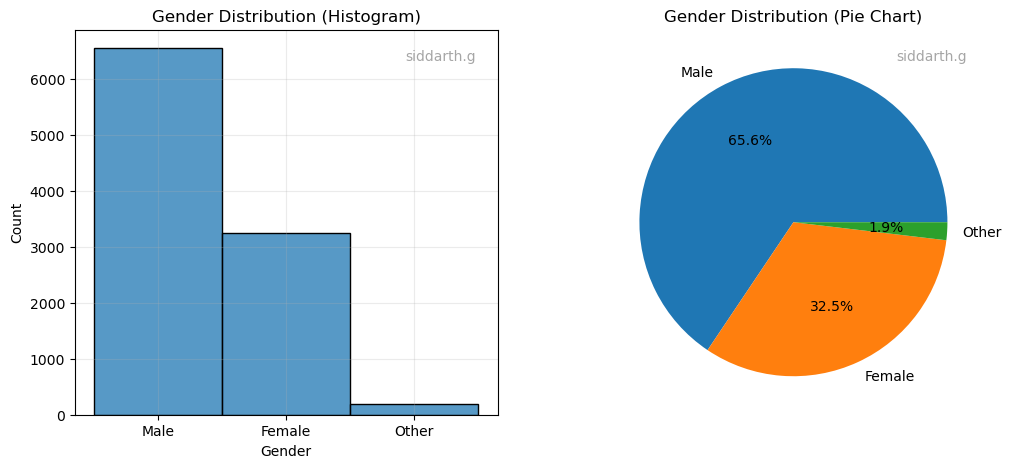

Gender
Male      6559
Female    3254
Other      187
Name: count, dtype: int64
Plotting Major Distribution


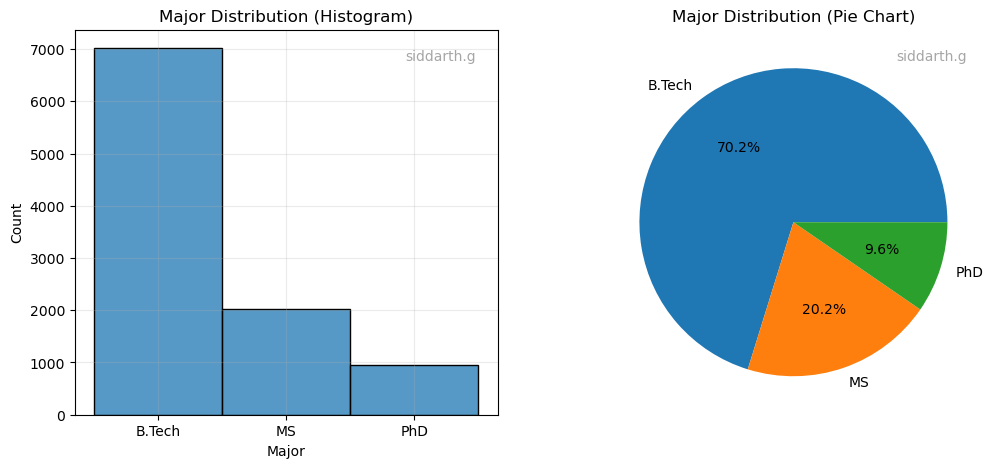

Major
B.Tech    7021
MS        2020
PhD        959
Name: count, dtype: int64
Plotting Program Distribution


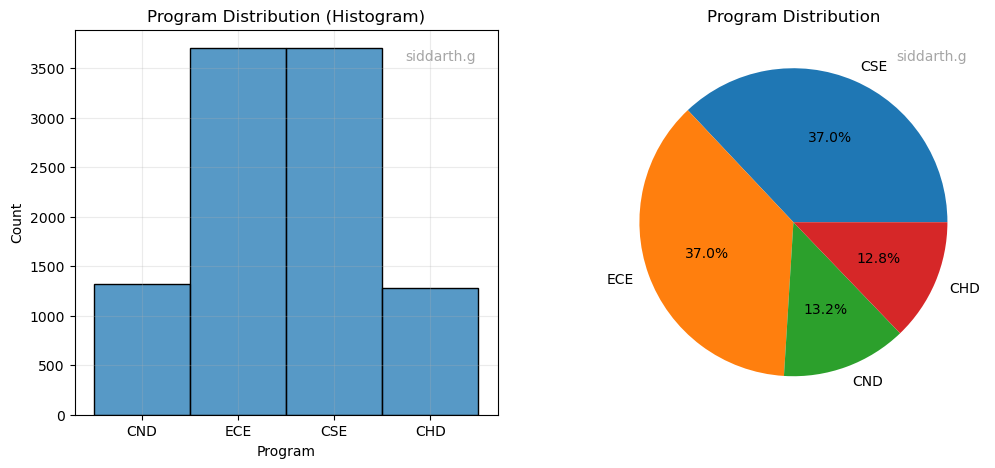

Program
CSE    3703
ECE    3699
CND    1316
CHD    1282
Name: count, dtype: int64
Plotting GPA Distribution


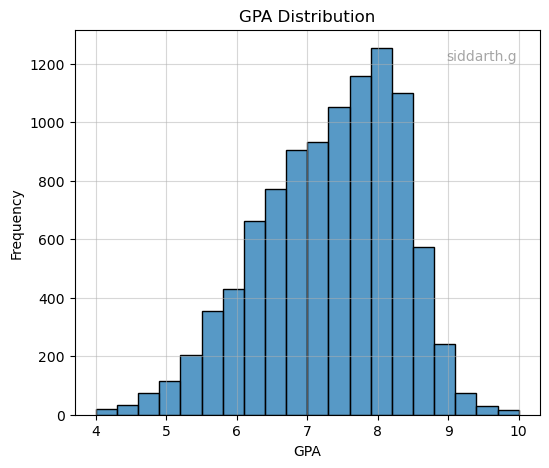

count    10000.000000
mean         7.321789
std          0.988180
min          4.000000
25%          6.639795
50%          7.448509
75%          8.091548
max         10.000000
Name: GPA, dtype: float64
Plotting Program by Major


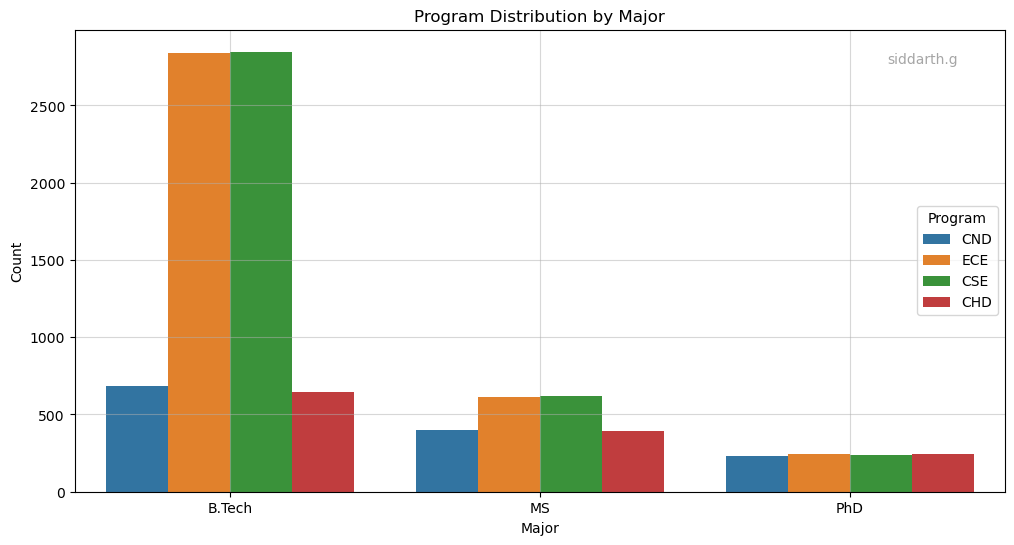

Major   Program
B.Tech  CSE        2848
        ECE        2841
        CND         686
        CHD         646
MS      CSE         617
        ECE         614
        CND         398
        CHD         391
PhD     CHD         245
        ECE         244
        CSE         238
        CND         232
Name: count, dtype: int64
Plotting GPA by Major


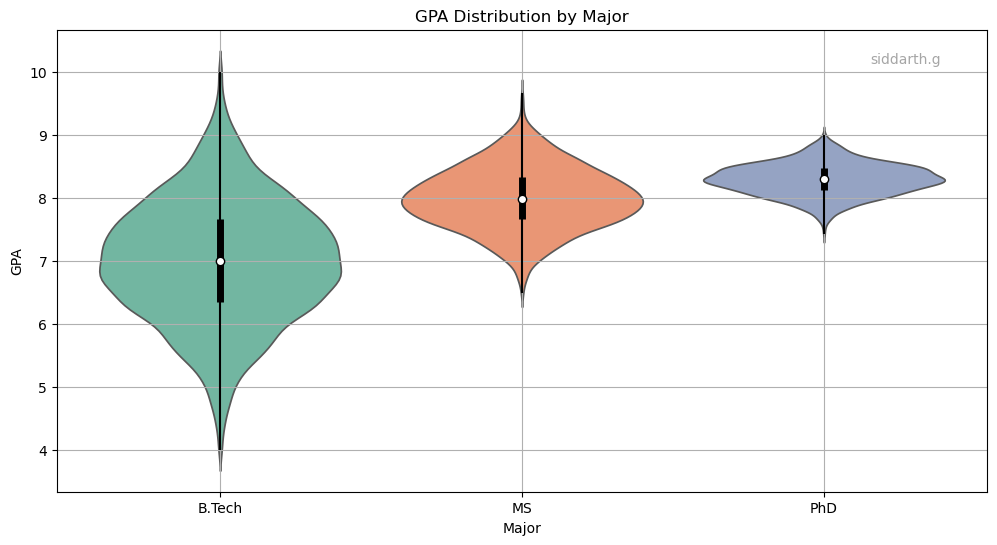

         count      mean       std       min       25%       50%       75%  \
Major                                                                        
B.Tech  7021.0  6.996567  0.974625  4.000000  6.342141  6.995691  7.656778   
MS      2020.0  7.992062  0.489897  6.480430  7.657940  7.981548  8.326876   
PhD      959.0  8.290952  0.250929  7.417893  8.126732  8.290015  8.463395   

              max  
Major              
B.Tech  10.000000  
MS       9.660461  
PhD      8.998387  
Plotting GPA by Program


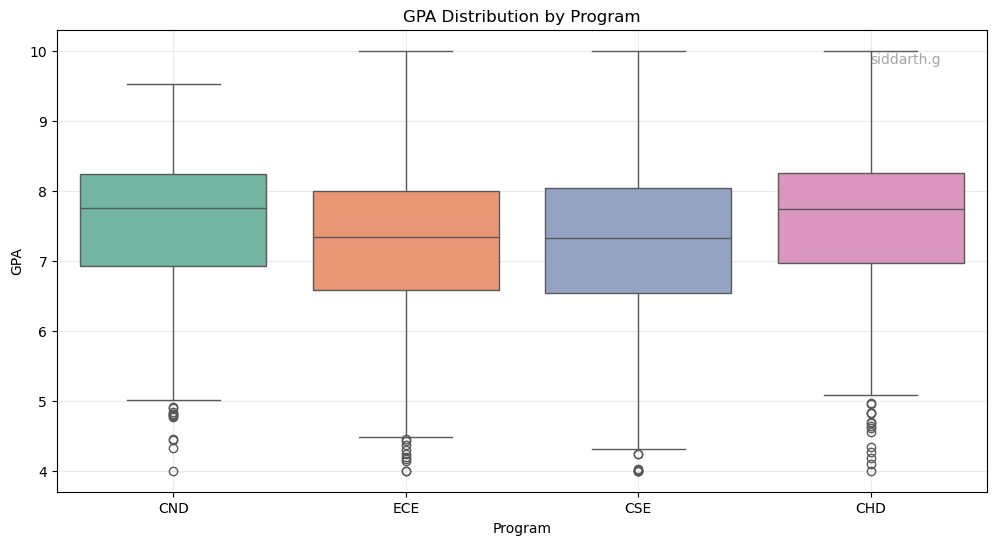

          count      mean       std  min       25%       50%       75%  \
Program                                                                  
CHD      1282.0  7.529930  0.940818  4.0  6.963971  7.734465  8.248682   
CND      1316.0  7.537763  0.908724  4.0  6.930012  7.746163  8.232166   
CSE      3703.0  7.244866  1.011608  4.0  6.538216  7.331073  8.036872   
ECE      3699.0  7.249819  0.986363  4.0  6.585582  7.334471  7.999438   

              max  
Program            
CHD      10.00000  
CND       9.52766  
CSE      10.00000  
ECE      10.00000  
Plotting GPA by Program and Major


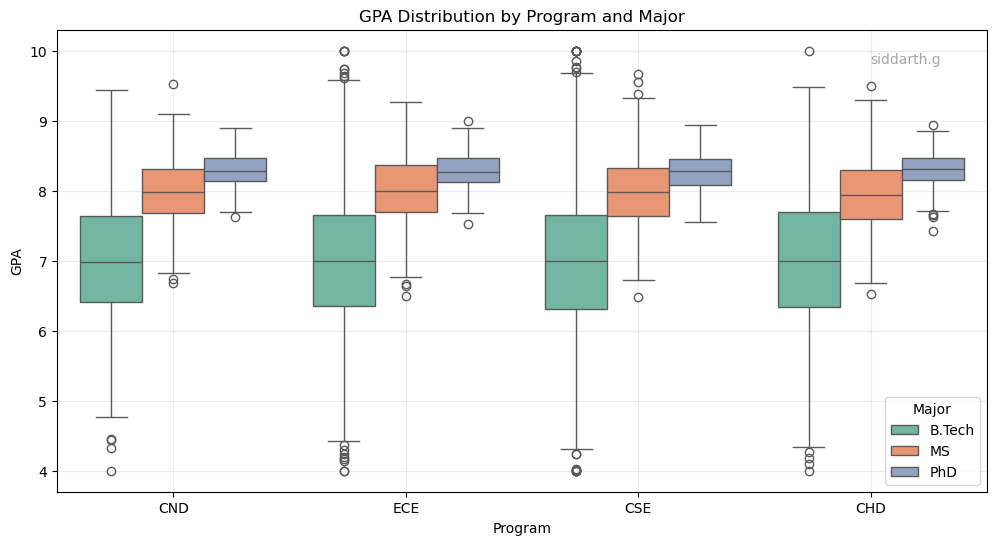

                 count      mean       std       min       25%       50%  \
Program Major                                                              
CHD     B.Tech   646.0  6.986210  0.975664  4.000000  6.338053  7.000453   
        MS       391.0  7.944208  0.507430  6.519826  7.603086  7.944391   
        PhD      245.0  8.302421  0.249324  7.417893  8.154194  8.306176   
CND     B.Tech   686.0  7.015924  0.924981  4.000000  6.410249  6.987797   
        MS       398.0  7.997167  0.457666  6.685952  7.681947  7.979929   
        PhD      232.0  8.292670  0.243047  7.631472  8.135890  8.285053   
CSE     B.Tech  2848.0  6.994614  0.998004  4.000000  6.303331  6.989585   
        MS       617.0  8.000550  0.496103  6.480430  7.644584  7.985983   
        PhD      238.0  8.280410  0.253829  7.557357  8.088424  8.288314   
ECE     B.Tech  2841.0  6.996206  0.962722  4.000000  6.360190  7.001723   
        MS       614.0  8.010698  0.491713  6.492070  7.690505  8.001462   
        PhD 

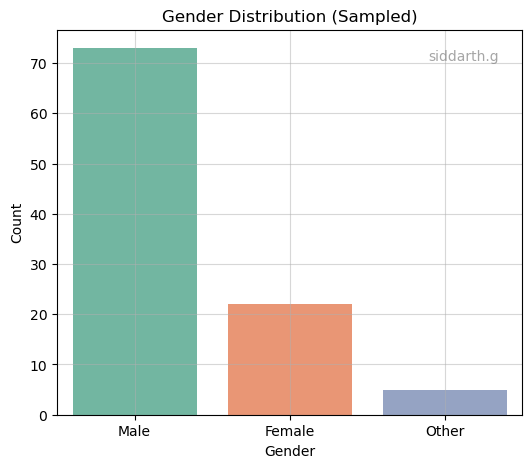

Gender
Male      73
Female    22
Other      5
Name: count, dtype: int64


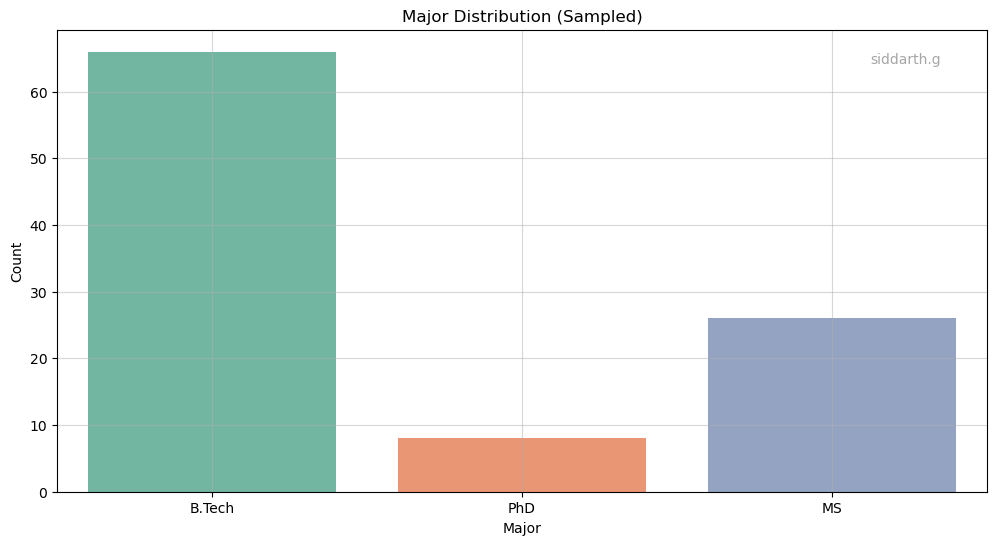

Major
B.Tech    66
MS        26
PhD        8
Name: count, dtype: int64


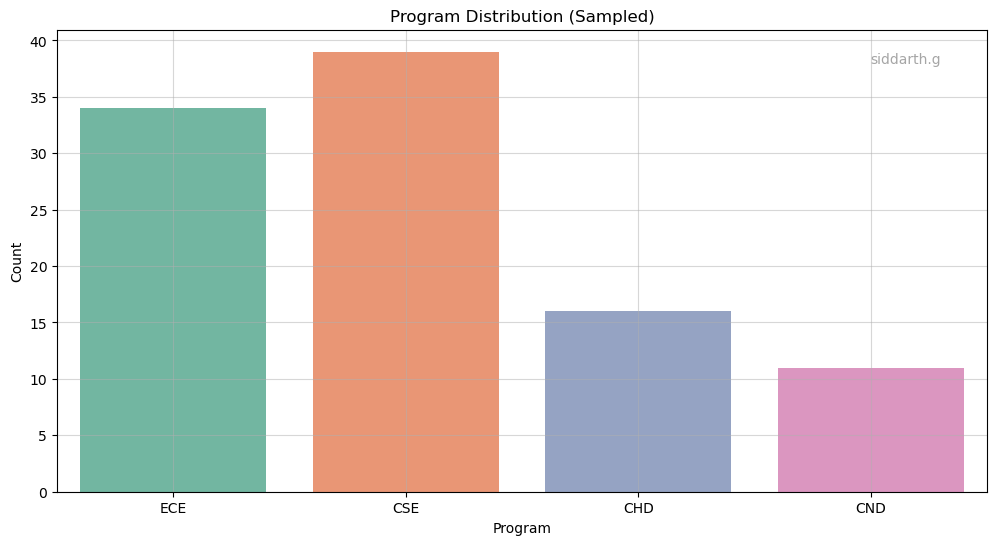

Program
CSE    39
ECE    34
CHD    16
CND    11
Name: count, dtype: int64


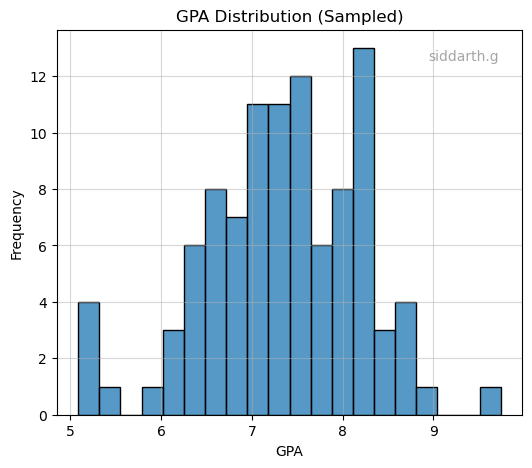

count    100.000000
mean       7.341792
std        0.883727
min        5.086796
25%        6.760934
50%        7.315244
75%        7.991066
max        9.742737
Name: GPA, dtype: float64
Plotting Entire Dataset Summary


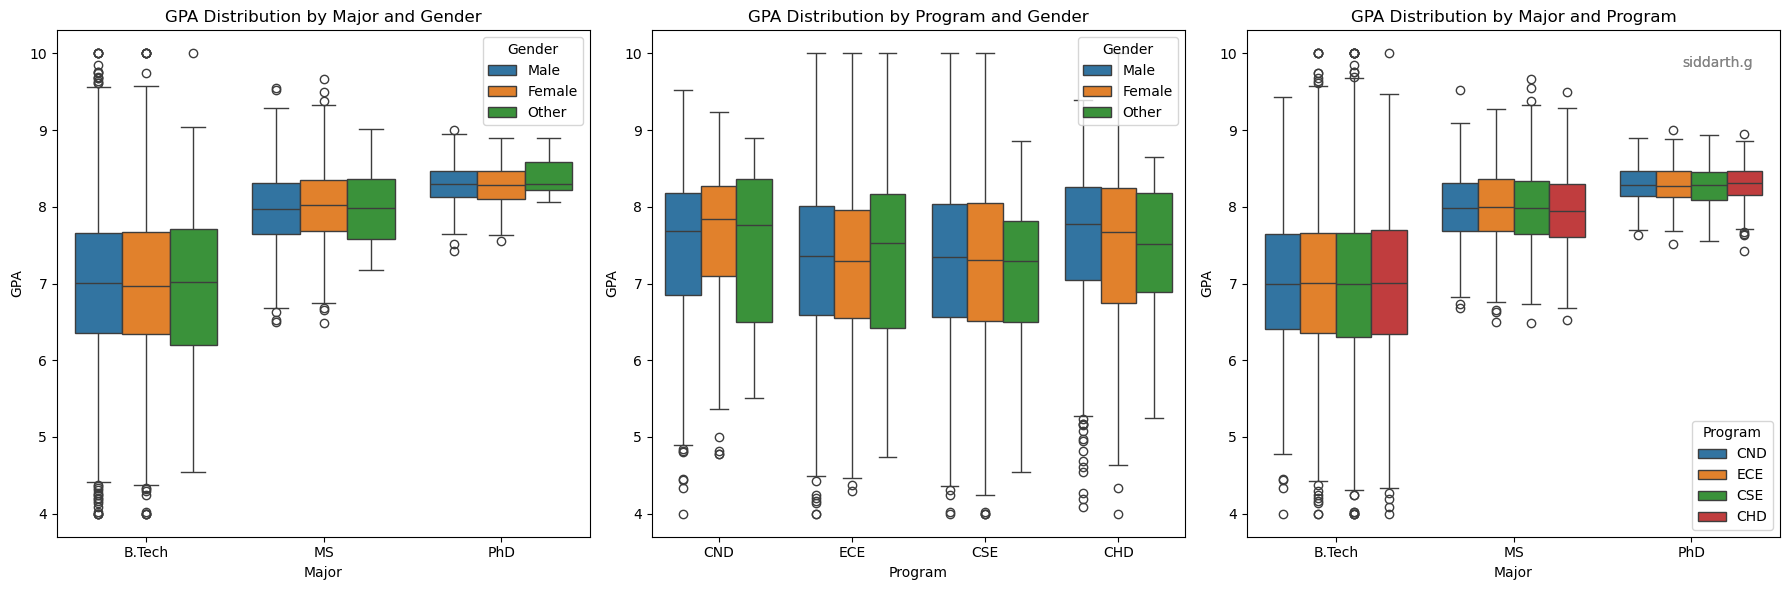

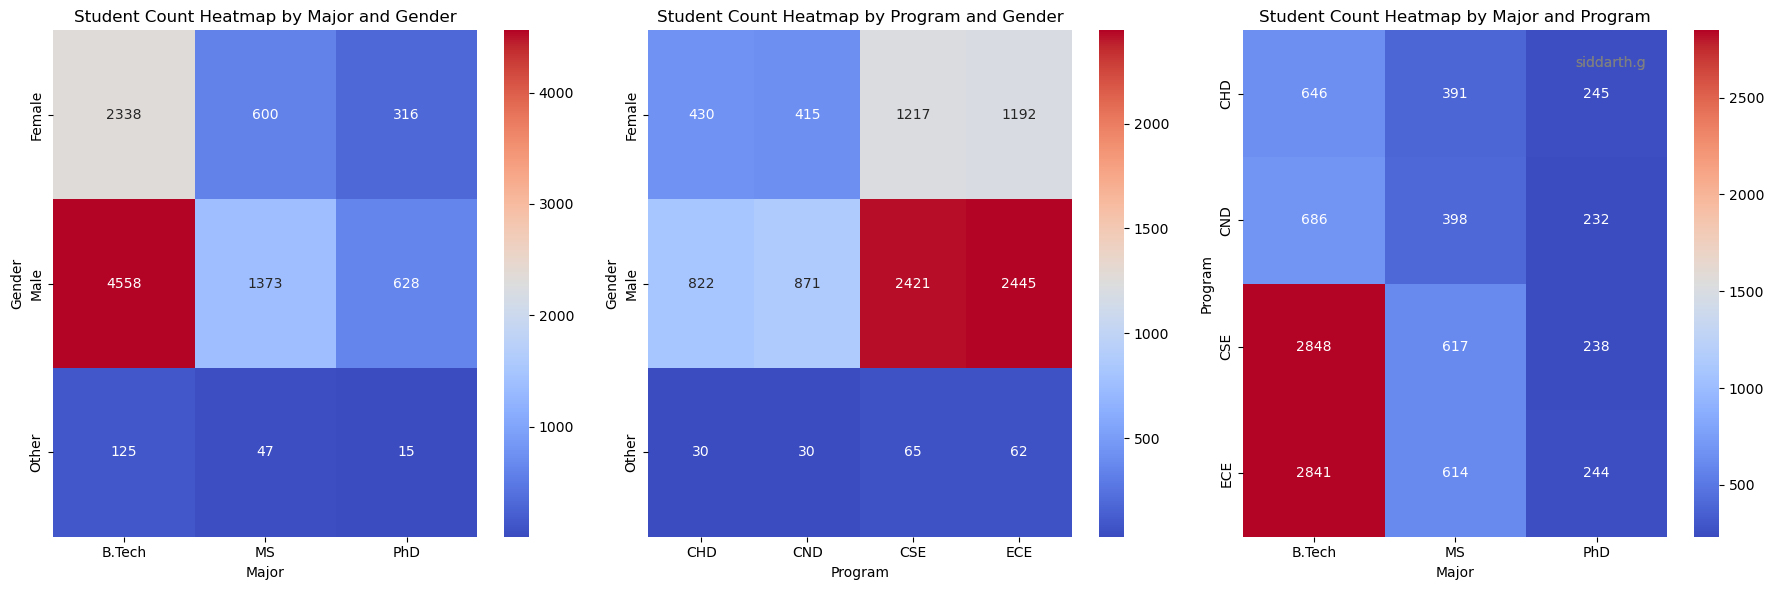

Statistics of GPA distribution
Mean GPA: 7.3217885696706855
Standard Deviation of GPA: 0.9881804354457135
The expected value of the mean was 0.7*7 + 0.2*8 + 0.1*8.3 = 7.33
The expected value of the standard deviation is typically higher than the standard deviations of each of the majors because of the different sample sizes and distributions.
The GPA mean increases with academic level (B.Tech < MS < PhD) while the GPA variance decreases, indicating that higher-level students perform more consistently at a higher level.
Statistics of students by (Program, Major) pairs
   Program   Major  Count
0      CHD  B.Tech    646
1      CHD      MS    391
2      CHD     PhD    245
3      CND  B.Tech    686
4      CND      MS    398
5      CND     PhD    232
6      CSE  B.Tech   2848
7      CSE      MS    617
8      CSE     PhD    238
9      ECE  B.Tech   2841
10     ECE      MS    614
11     ECE     PhD    244
Heatmap of Students by (Program, Major) pairs


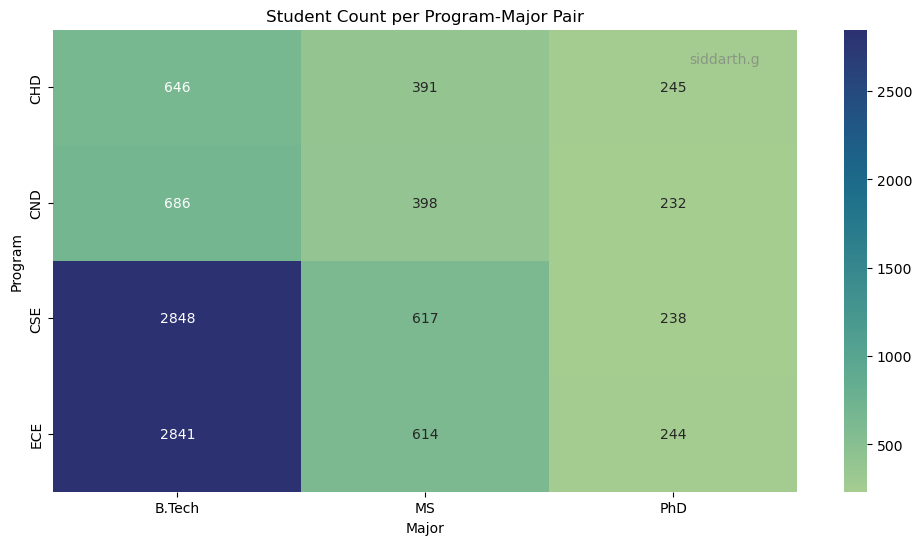

The program-major heatmap shows that B.Tech students dominate the dataset, with most of them concentrated in CSE and ECE. MS students are more evenly distributed across programs, though still biased towards CSE/ECE, while PhD students are uniformly spread across all programs.
Random Sampling
Random Sampling Mean: 7.310947312953986
Random Sampling Std Dev: 0.0405220684150237
Stratified Sampling
Stratified Sampling Mean: 7.316659079117864
Stratified Sampling Std Dev: 0.033447510886587435
The standard deviation of the Stratified Sampling dataset is lower than random sampling. This is because stratified sampling ensures that each major is represented proportionally, leading to a more consistent GPA distribution across samples.
Gender counts:
[{'Male': 100, 'Female': 100, 'Other': 100}, {'Male': 100, 'Female': 100, 'Other': 100}, {'Male': 100, 'Female': 100, 'Other': 100}, {'Male': 100, 'Female': 100, 'Other': 100}, {'Male': 100, 'Female': 100, 'Other': 100}]
Sampling Strategy A results
[{'

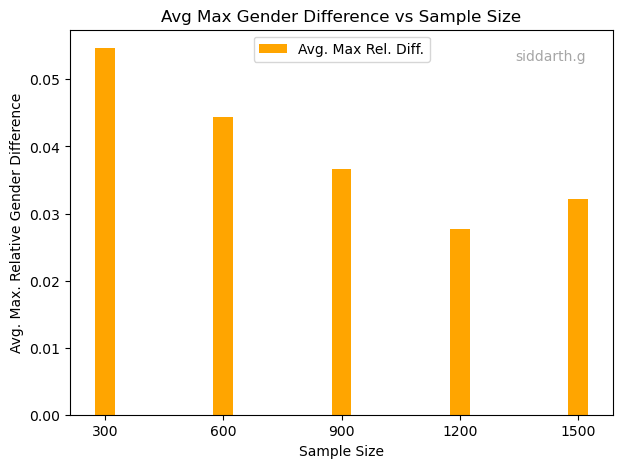

We would expect the values to decrease naturally. However, in our case due to the seed, the value increases slightly towards the end.
GPA's of 100 sampled students through strategy A
[10.0, 5.097671623206355, 4.199185106854124, 7.344846702556367, 5.7539463371656066]
Plotting GPA Histogram Comparison
WITHOUT REPLACEMENT


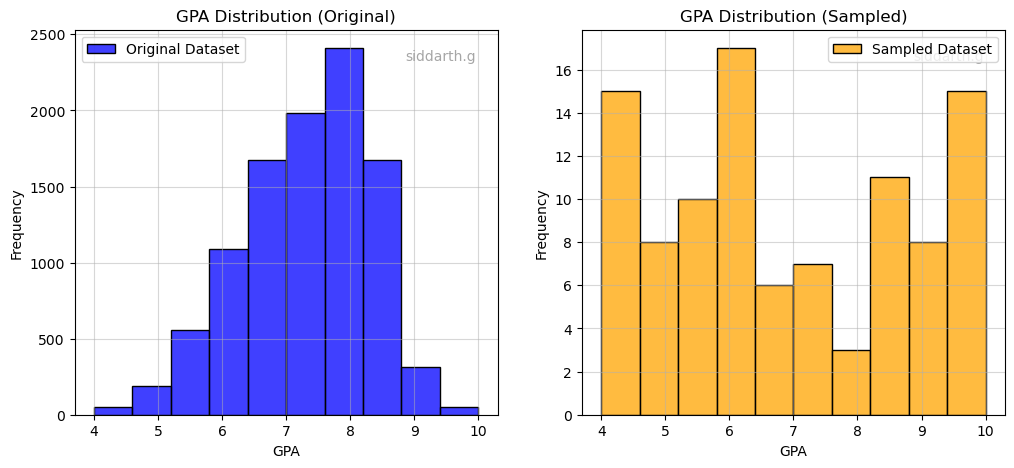

When we sample with replacement, there is a good chance, we might select the same student multiple times, leading to a biased representation of the GPA distribution. Thus, sampling without replacement is the preferred method. In my case, the random seed was generating results in such a manner that I did not need to replace students, i.e., none of my bins were emptied after sampling 100 students.
Sampling 60 students with balanced Program-Major pairs
Program: CND, Major: B.Tech - 686 students
Program: ECE, Major: B.Tech - 2841 students
Program: CSE, Major: B.Tech - 2848 students
Program: CHD, Major: B.Tech - 646 students
Program: CSE, Major: MS - 617 students
Program: CND, Major: MS - 398 students
Program: CSE, Major: PhD - 238 students
Program: CND, Major: PhD - 232 students
Program: CHD, Major: PhD - 245 students
Program: ECE, Major: MS - 614 students
Program: CHD, Major: MS - 391 students
Program: ECE, Major: PhD - 244 students
      Gender Major Program       GPA
8994    Male   PhD 

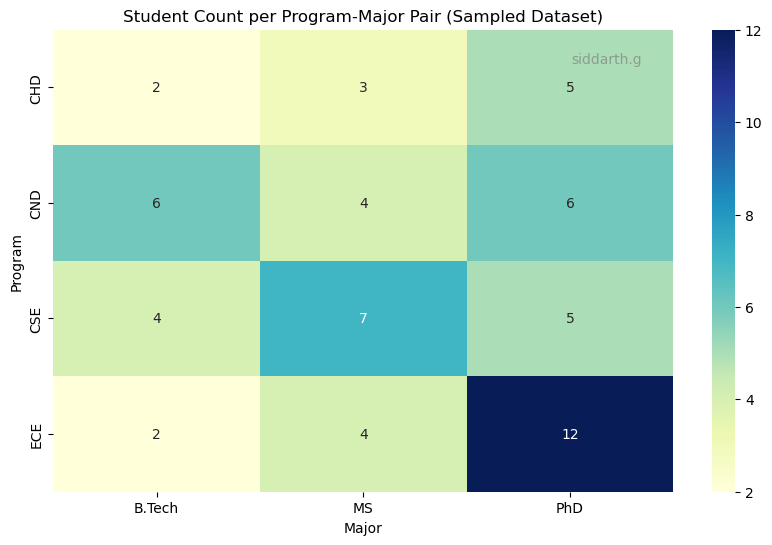

The groups are large enough to accomodate for the sampled students even in the worst case. Thus, we do not need to handle the cases of bins running out of students to sample.


In [8]:
if __name__ == "__main__":

    # Generating a personalized random seed
    username = "siddarth.g"
    seed = int(hashlib.sha256(username.encode()).hexdigest(), 16) % (2**32)
    print("Seed value : ", seed)
    print_separator()

    dataset = StudentDataset(num_students=10000, seed=seed, username=username)
    df = dataset.get_full_dataframe()
    print("Student Dataset size: ", df.shape)
    print(df.head())
    print(" .....")
    print(df.tail())
    print_separator()

    print("Plotting Gender Distribution")
    dataset.plot_gender_distribution()
    print_separator()

    print("Plotting Major Distribution")
    dataset.plot_major_distribution()
    print_separator()

    print("Plotting Program Distribution")
    dataset.plot_program_distribution()
    print_separator()

    print("Plotting GPA Distribution")
    dataset.plot_gpa_distribution()
    print_separator()

    print("Plotting Program by Major")
    dataset.plot_program_by_major()
    print_separator()

    print("Plotting GPA by Major")
    dataset.plot_gpa_by_major()
    print_separator()

    print("Plotting GPA by Program")
    dataset.plot_gpa_by_program()
    print_separator()

    print("Plotting GPA by Program and Major")
    dataset.plot_gpa_by_program_and_major()
    print_separator()

    print("Plotting Sampled Dataset")
    dataset.plot_sampled_dataset()
    print_separator()

    print("Plotting Entire Dataset Summary")
    dataset.plot_entire_dataset_summary()
    print_separator()

    print("Statistics of GPA distribution")
    mean, standard_deviation = dataset.gpa_mean_std()
    print("Mean GPA:", mean)
    print("Standard Deviation of GPA:", standard_deviation)
    print("The expected value of the mean was 0.7*7 + 0.2*8 + 0.1*8.3 = 7.33")
    print("The expected value of the standard deviation is typically higher than the standard deviations of each of the majors because of the different sample sizes and distributions.")
    print("The GPA mean increases with academic level (B.Tech < MS < PhD) while the GPA variance decreases, indicating that higher-level students perform more consistently at a higher level.")
    print_separator()

    print("Statistics of students by (Program, Major) pairs")
    print(dataset.count_students_per_program_major_pair())
    print_separator()

    print("Heatmap of Students by (Program, Major) pairs")
    dataset.visualize_students_per_program_major_pair(dataset.count_students_per_program_major_pair())
    print("The program-major heatmap shows that B.Tech students dominate the dataset, with most of them concentrated in CSE and ECE. MS students are more evenly distributed across programs, though still biased towards CSE/ECE, while PhD students are uniformly spread across all programs.")
    print_separator()

    #----------------- Q1.2 -----------------

    print("Random Sampling")
    random_mean, random_std = dataset.get_gpa_mean_std_random(n = 500, repeats = 50)
    print("Random Sampling Mean:", random_mean)
    print("Random Sampling Std Dev:", random_std)
    print_separator()

    print("Stratified Sampling")
    stratified_mean, stratified_std = dataset.get_gpa_mean_std_stratified(n = 500, repeats = 50)
    print("Stratified Sampling Mean:", stratified_mean)
    print("Stratified Sampling Std Dev:", stratified_std)
    print("The standard deviation of the Stratified Sampling dataset is lower than random sampling. This is because stratified sampling ensures that each major is represented proportionally, leading to a more consistent GPA distribution across samples.")
    print_separator()

    #----------------- Q1.3 -----------------

    print("Gender counts:")
    print(dataset.get_gender_balanced_counts(n=300, repeats=5))
    print_separator()

    print("Sampling Strategy A results")
    print(dataset.sample_gender_uniform_random(n=300, repeats=5, replace=False))
    print_separator()

    print("Plotting Histogram of Average Maximum Relative Difference in Gender Counts")
    print("WITH REPLACEMENT")
    dataset.plot_avg_max_gender_diff_vs_sample_size(sample_sizes = [300, 600, 900, 1200, 1500], repeats=10, replace=True)
    # print("WITHOUT REPLACEMENT")
    # dataset.plot_avg_max_gender_diff_vs_sample_size(sample_sizes = [300, 600, 900, 1200, 1500], repeats=10, replace=False)
    print("We would expect the values to decrease naturally. However, in our case due to the seed, the value increases slightly towards the end.")
    print_separator()

    #----------------- Q1.4 -----------------

    print("GPA's of 100 sampled students through strategy A")
    # sampled_students_rep = dataset.sample_gpa_uniform(n=100, bins=10, replace=True)
    # print(sampled_students_rep[:5])
    sampled_students_no_rep = dataset.sample_gpa_uniform(n=100, bins=10, replace=False)
    print(sampled_students_no_rep[:5])
    print_separator()

    print("Plotting GPA Histogram Comparison")
    # print("WITH REPLACEMENT")
    # dataset.plot_gpa_histogram_comparison(sampled_students_rep)
    print("WITHOUT REPLACEMENT")
    dataset.plot_gpa_histogram_comparison(sampled_students_no_rep)
    print_separator()

    print("When we sample with replacement, there is a good chance, we might select the same student multiple times, leading to a biased representation of the GPA distribution. Thus, sampling without replacement is the preferred method. In my case, the random seed was generating results in such a manner that I did not need to replace students, i.e., none of my bins were emptied after sampling 100 students.")
    print_separator()

    #----------------- Q1.5 -----------------

    print("Sampling 60 students with balanced Program-Major pairs")
    samples = dataset.sample_program_major_balanced(n=60, replace=False)
    print(samples.head())
    print_separator()

    print("Plotting the sampled data")
    dataset.show_program_major_counts_and_heatmap(samples)
    print("The groups are large enough to accomodate for the sampled students even in the worst case. Thus, we do not need to handle the cases of bins running out of students to sample.")
    print_separator()